## Load Libraries

In [11]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
classification_report,roc_auc_score)

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Load Dataset

In [12]:
df = pd.read_csv("Sales_Performance_Dataset.csv")

## Fisrt Look

df.head()

In [8]:
df.shape

(50000, 24)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          50000 non-null  object 
 1   Order_Date        50000 non-null  object 
 2   Customer_ID       50000 non-null  object 
 3   Customer_Name     50000 non-null  object 
 4   Gender            50000 non-null  object 
 5   Age               50000 non-null  int64  
 6   City              50000 non-null  object 
 7   State             50000 non-null  object 
 8   Region            50000 non-null  object 
 9   Product_ID        50000 non-null  object 
 10  Product_Name      50000 non-null  object 
 11  Category          50000 non-null  object 
 12  Sub_Category      50000 non-null  object 
 13  Brand             50000 non-null  object 
 14  Quantity          50000 non-null  int64  
 15  Unit_Price        50000 non-null  float64
 16  Discount_Percent  50000 non-null  int64 

In [11]:
df.describe()

,Age,Quantity,Unit_Price,Discount_Percent,Sales,Cost,Profit
count,50000.0000,50000.0000,50000.00000,50000.000,50000.000000,50000.000000,50000.000000
mean,41.4417,3.0006,2559.65524,14.943,6528.884033,4735.400613,1793.483419
...,...,...,...,...,...,...,...
75%,53.0000,4.0000,3783.89000,25.000,9554.812500,6898.147500,2515.335000
max,65.0000,5.0000,4999.95000,30.000,24986.750000,22088.440000,11035.710000


In [13]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender',
       'Age', 'City', 'State', 'Region', 'Product_ID', 'Product_Name',
       'Category', 'Sub_Category', 'Brand', 'Quantity', 'Unit_Price',
       'Discount_Percent', 'Sales', 'Cost', 'Profit', 'Payment_Method',
       'Sales_Channel', 'Sales_Person', 'Customer_Type'],
      dtype='object')

In [13]:
## Duplicate Values

In [14]:
df.duplicated().sum()

0

In [15]:
## Missing Values

In [16]:
df.isnull().sum()

Order_ID         0
Order_Date       0
                ..
Sales_Person     0
Customer_Type    0
Length: 24, dtype: int64

In [17]:
## Target Column

In [18]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Customer_Name',
 'Gender',
 'Age',
 'City',
 'State',
 'Region',
 'Product_ID',
 'Product_Name',
 'Category',
 'Sub_Category',
 'Brand',
 'Quantity',
 'Unit_Price',
 'Discount_Percent',
 'Sales',
 'Cost',
 'Profit',
 'Payment_Method',
 'Sales_Channel',
 'Sales_Person',
 'Customer_Type']

In [19]:
df["Payment_Method"].unique()

array(['UPI', 'Debit Card', 'Net Banking', 'Cash', 'Credit Card'],
      dtype=object)

In [20]:
df["Category"].unique()

array(['Electronics', 'Furniture', 'Clothing', 'Home', 'Sports',
       'Grocery'], dtype=object)

In [21]:
## Create Target Column

In [14]:
conditions = (
    (df["Discount_Percent"] >= 25).astype(int) +
    (df["Quantity"] >= 3).astype(int) +
    (df["Category"].isin(["Electronics", "Clothing"])).astype(int) +
    (df["Payment_Method"] == "Cash").astype(int)
)

df["returned"] = np.where(conditions >= 2, 1, 0)

 ## Check Target Distribution

In [15]:
df["returned"].value_counts()

returned
0    27848
1    22152
Name: count, dtype: int64

## EDA (Exploratory Data Analysis

## Target Variable Distribution

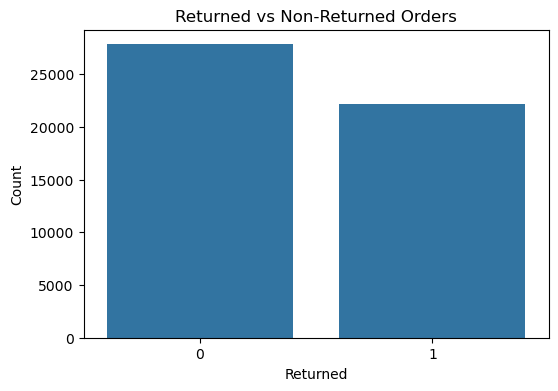

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="returned")

plt.title("Returned vs Non-Returned Orders")
plt.xlabel("Returned")
plt.ylabel("Count")

plt.show()

In [25]:
df["returned"].value_counts(normalize=True) * 100

returned
0    55.696
1    44.304
Name: proportion, dtype: float64

In [92]:
numerical_cols = df.select_dtypes(include=["int64","float64"]).columns
numerical_cols

Index(['Age', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Sales', 'Cost',
       'Profit'],
      dtype='object')

## Distribution of Numerical Feature

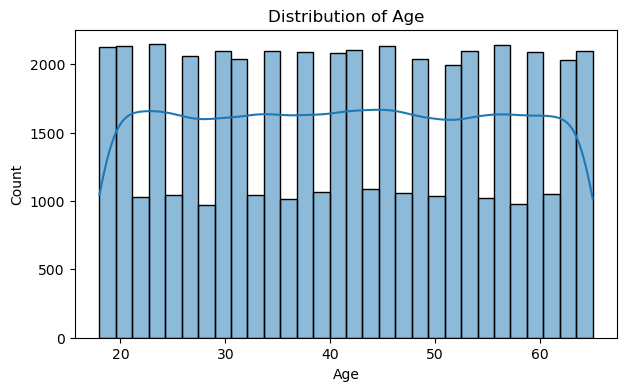

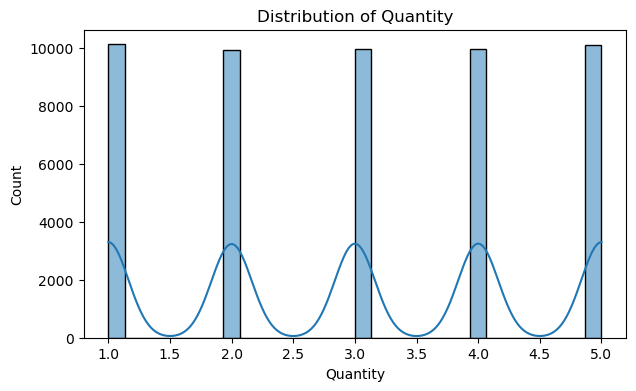

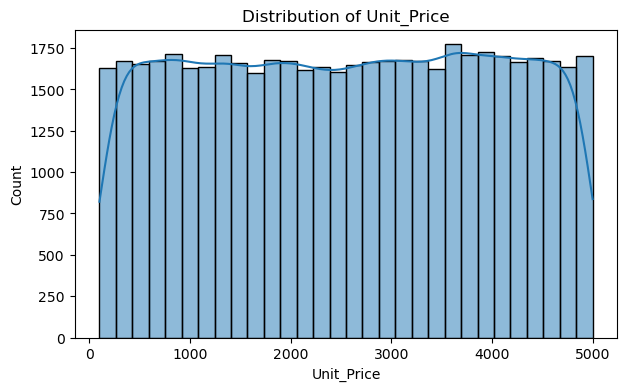

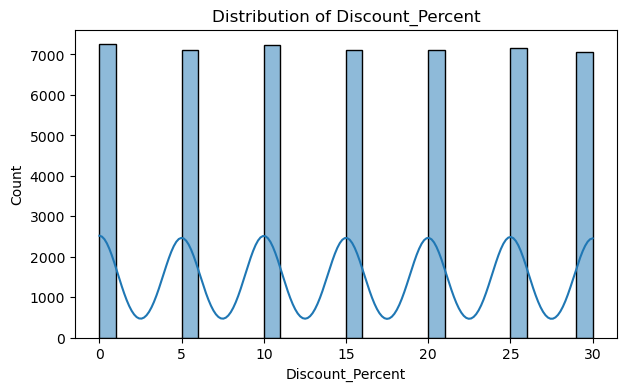

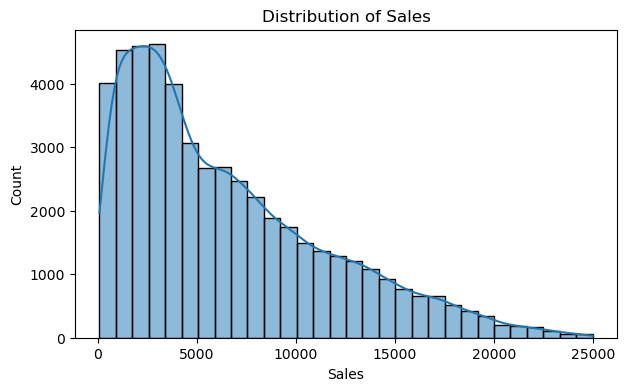

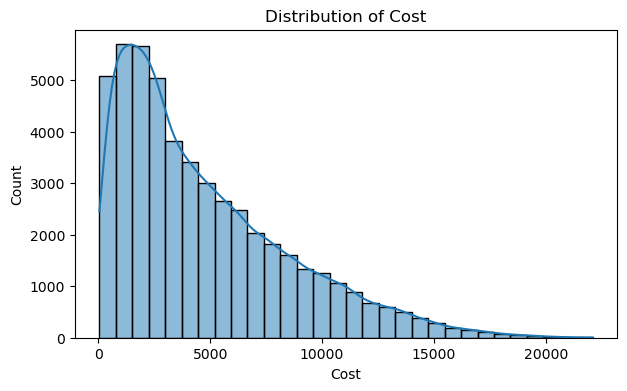

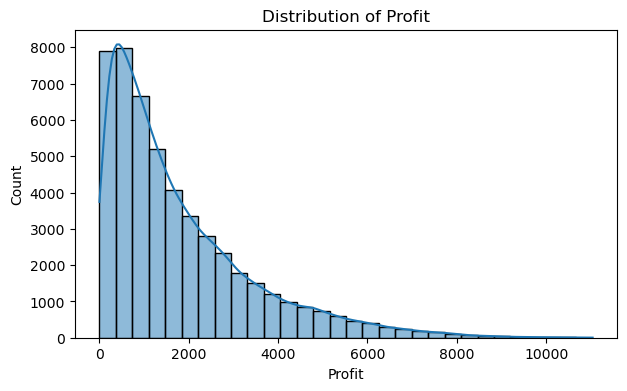

In [93]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], bins=30, kde=True)

    plt.title(f"Distribution of {col}")
    plt.show()

## Boxplot (Outlier Detection)

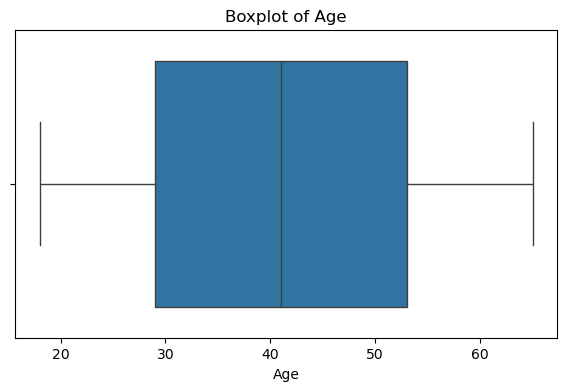

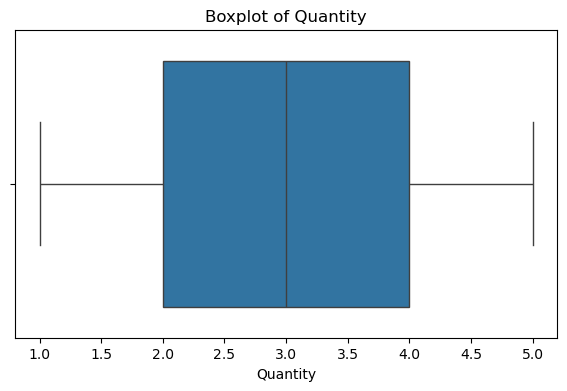

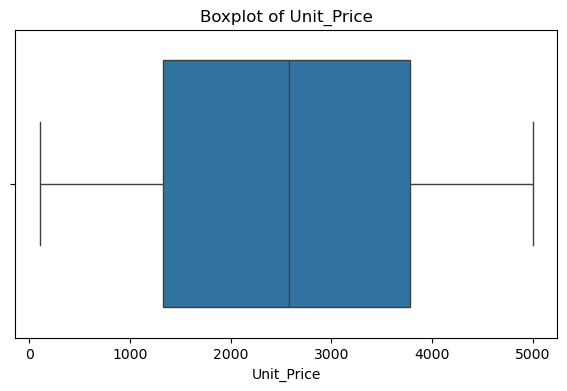

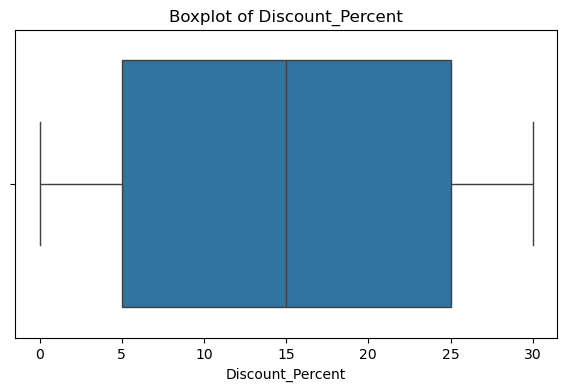

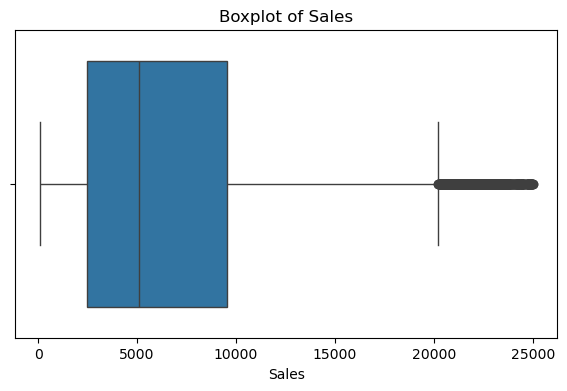

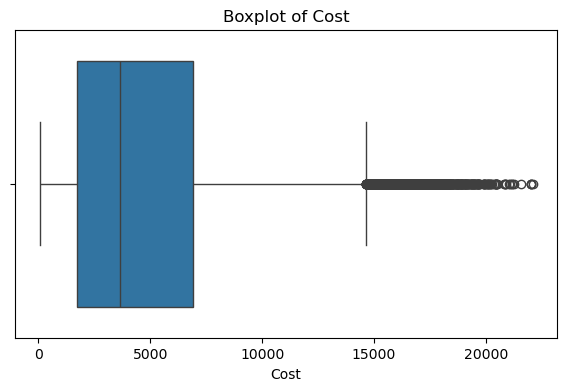

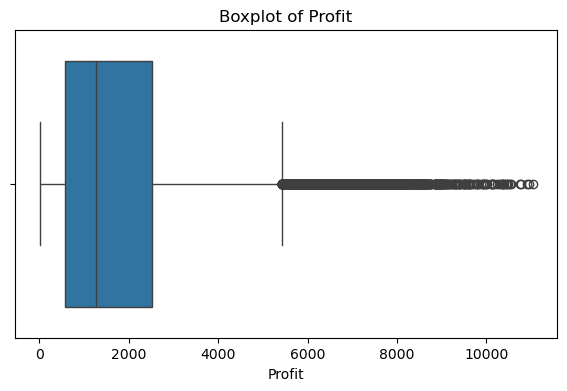

In [94]:
for col in numerical_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

## Count Plot of Every Categorical Column

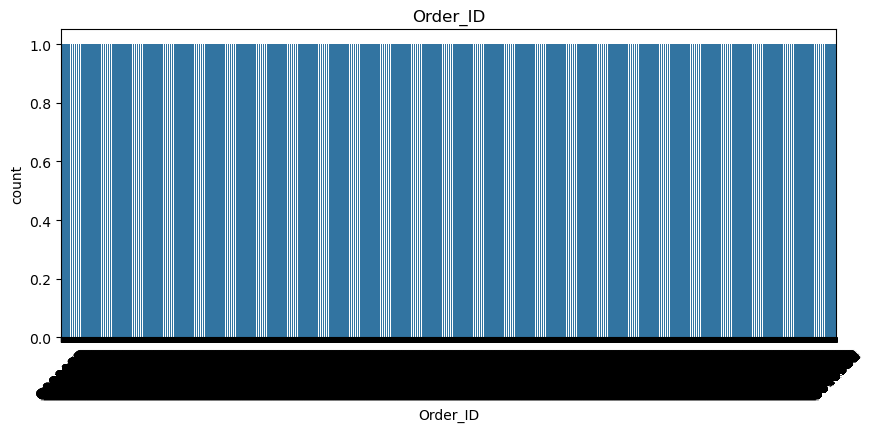

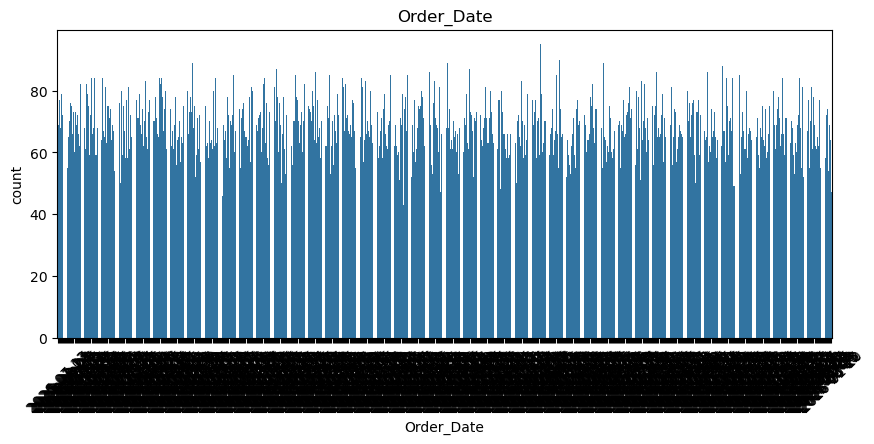

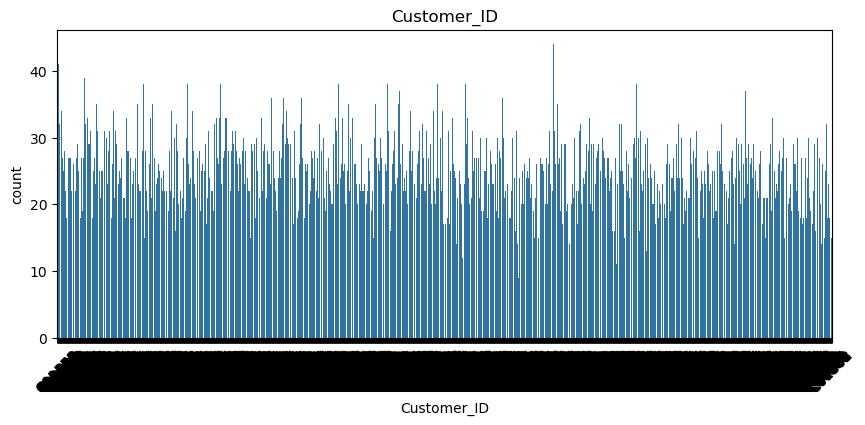

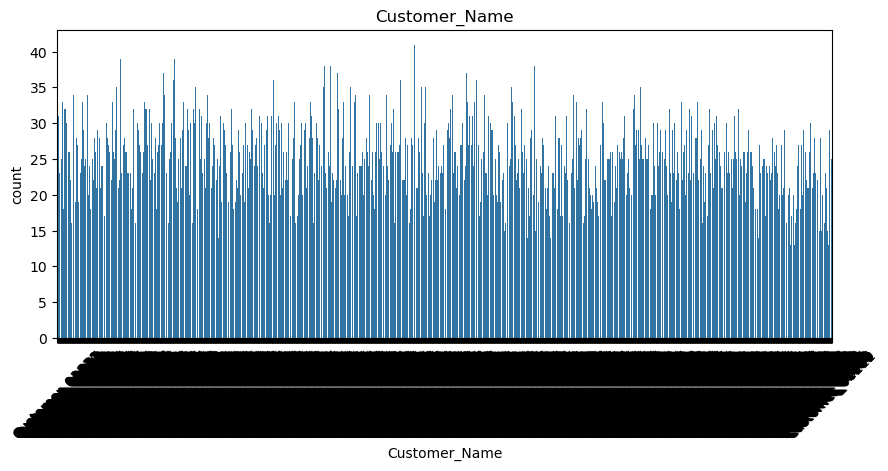

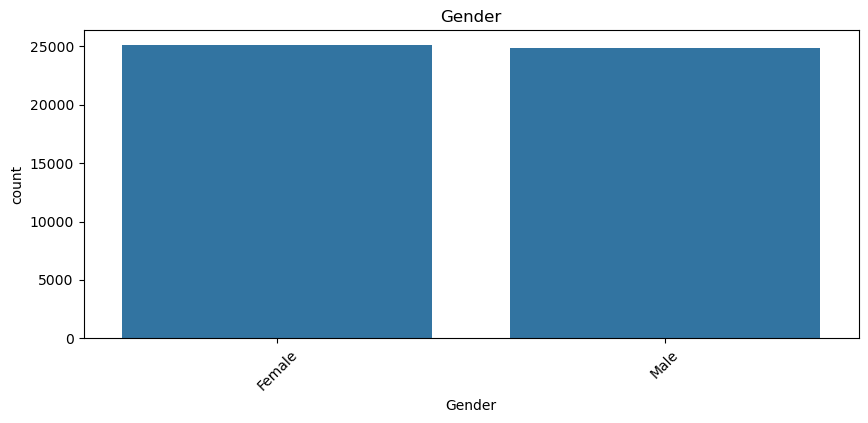

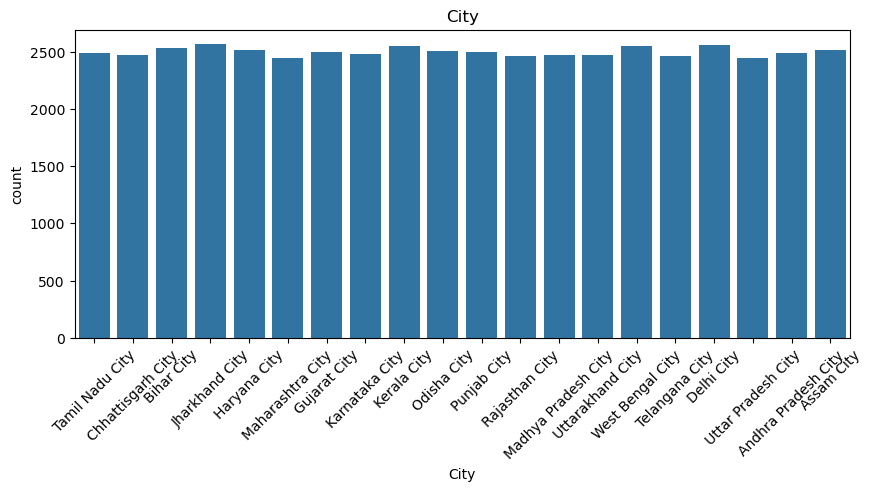

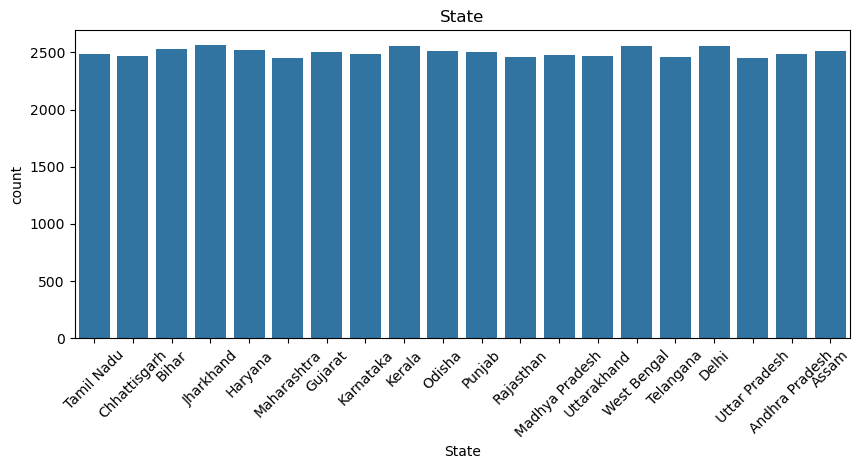

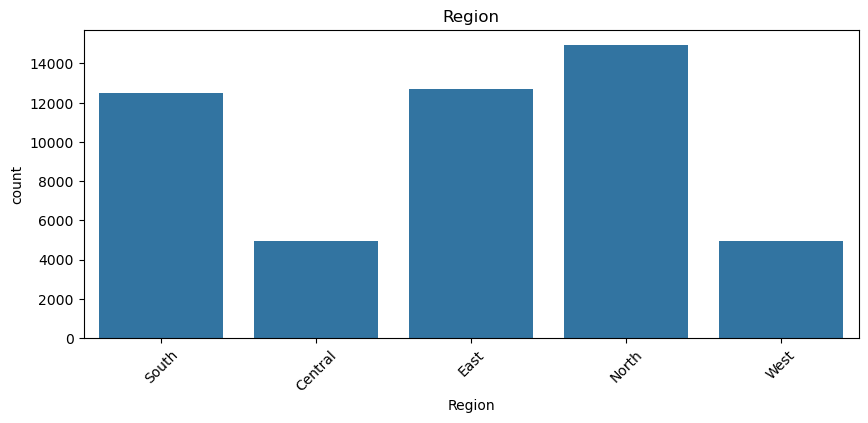

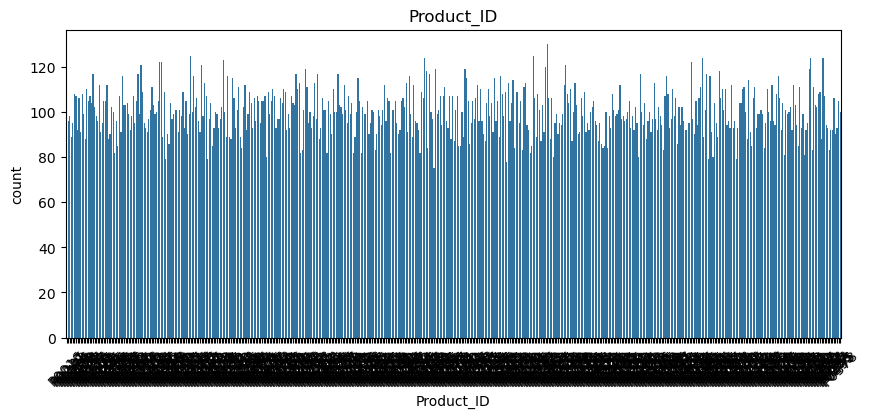

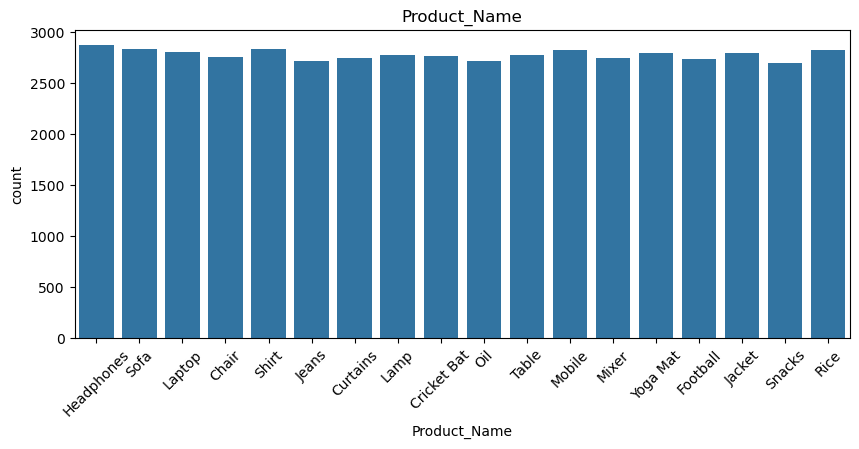

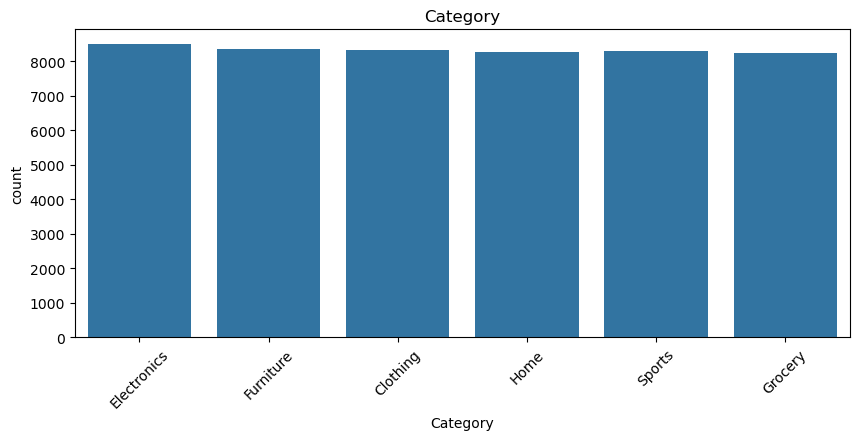

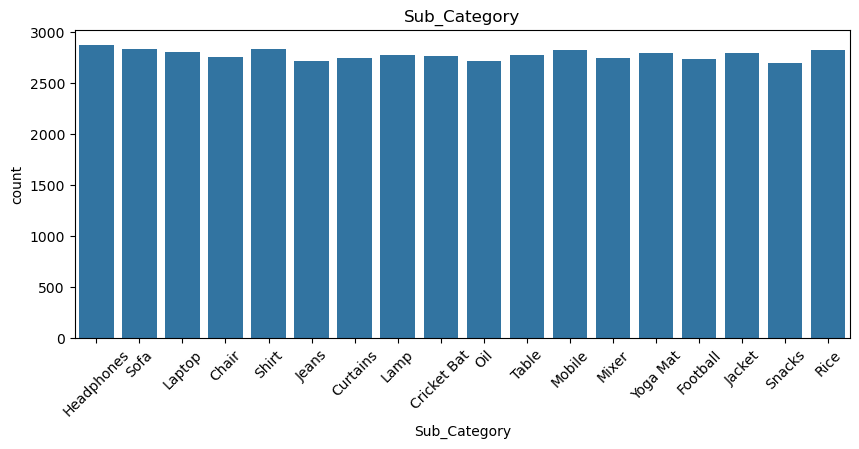

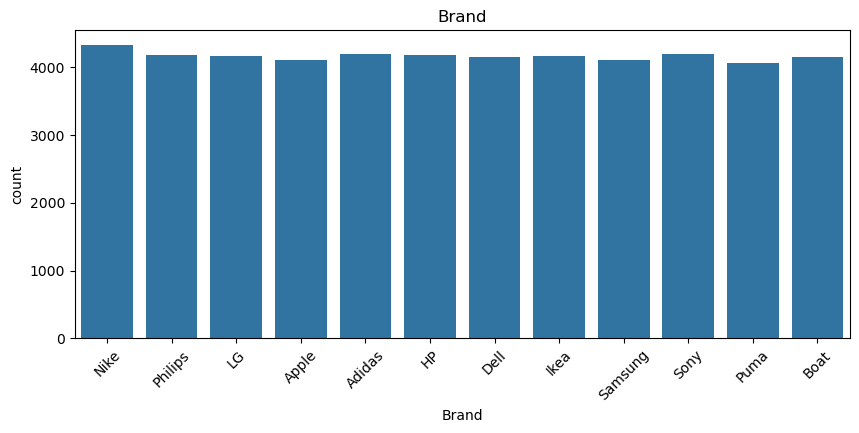

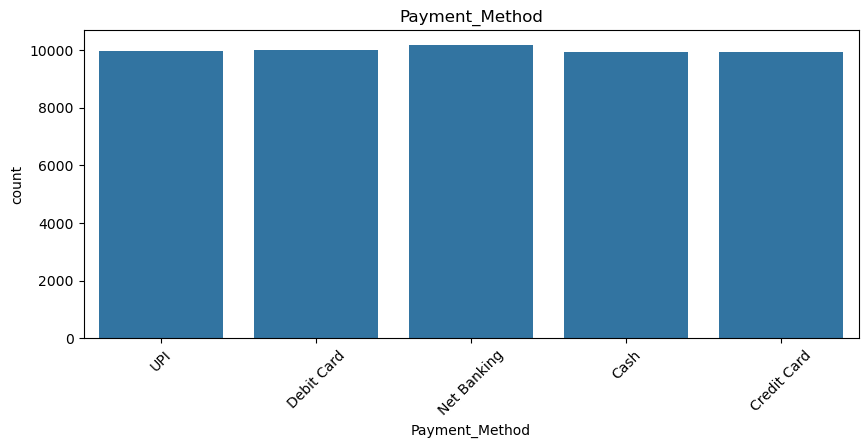

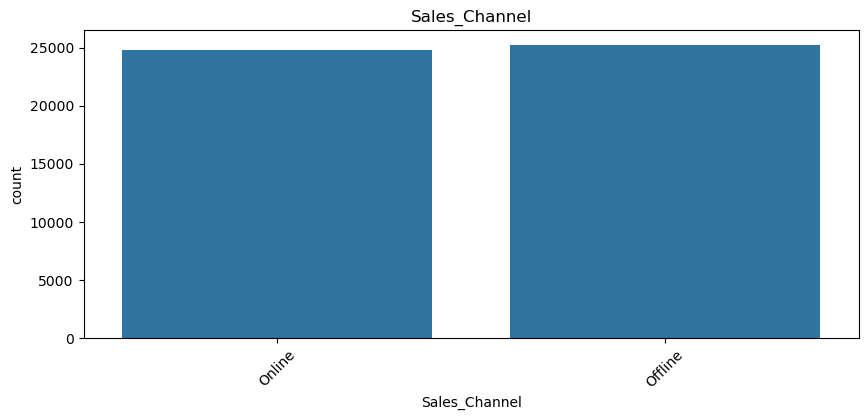

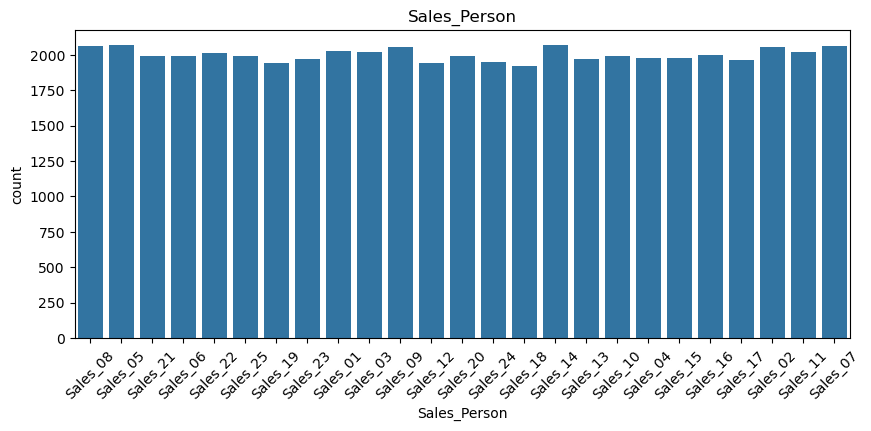

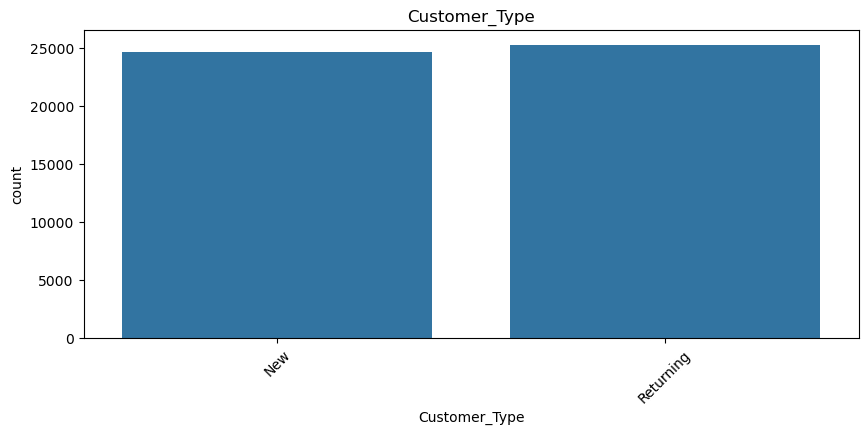

In [6]:
for col in categorical_cols:

    plt.figure(figsize=(10,4))

    sns.countplot(data=df, x=col)

    plt.xticks(rotation=45)

    plt.title(col)

    plt.show()

## Category-wise Sales

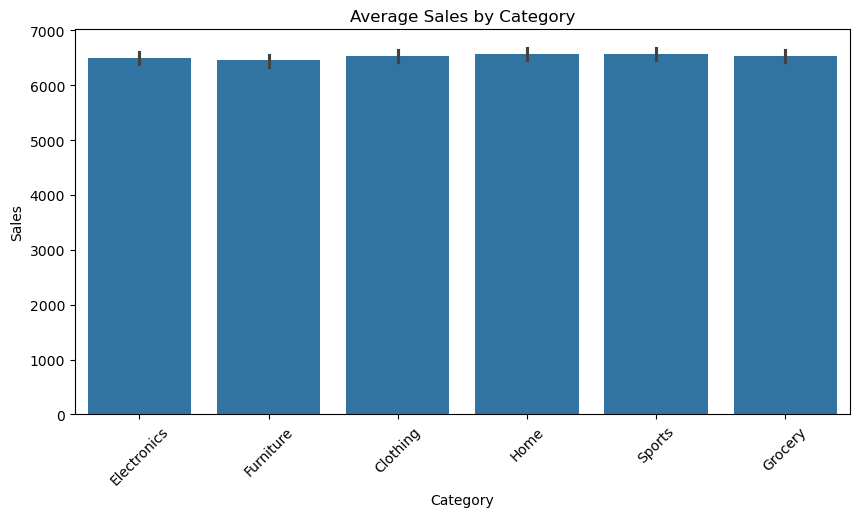

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="mean"
)

plt.title("Average Sales by Category")
plt.xticks(rotation=45)

plt.show()

## Category-wise Profit

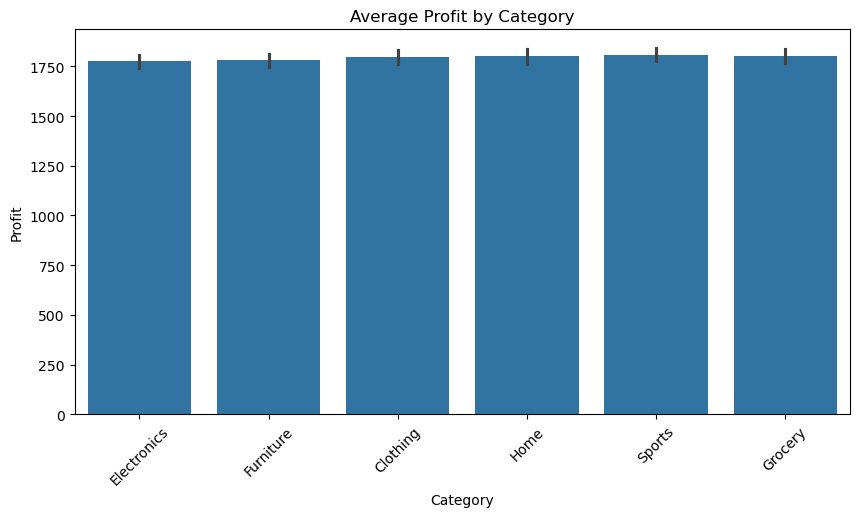

In [8]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x="Category",
    y="Profit",
    estimator="mean"
)

plt.title("Average Profit by Category")
plt.xticks(rotation=45)

plt.show()

## Region-wise Sales

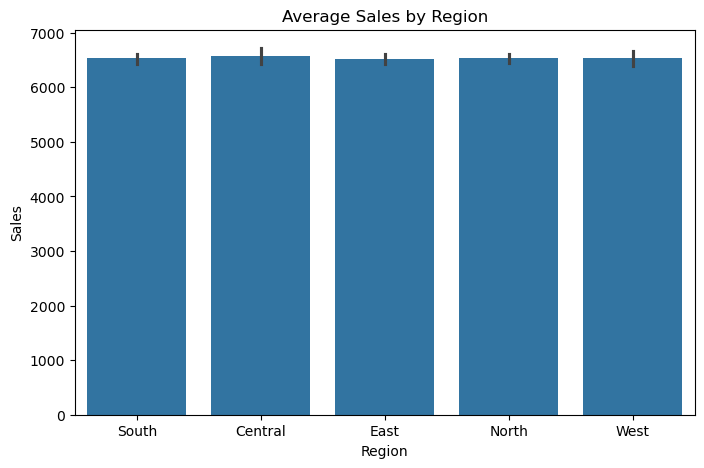

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator="mean"
)

plt.title("Average Sales by Region")

plt.show()

## Payment Method Distribution

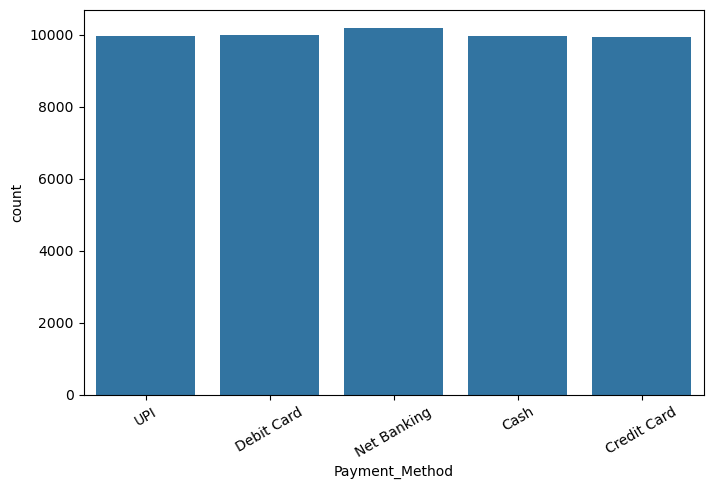

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Payment_Method"
)

plt.xticks(rotation=30)

plt.show()

## Returned vs Customer Type

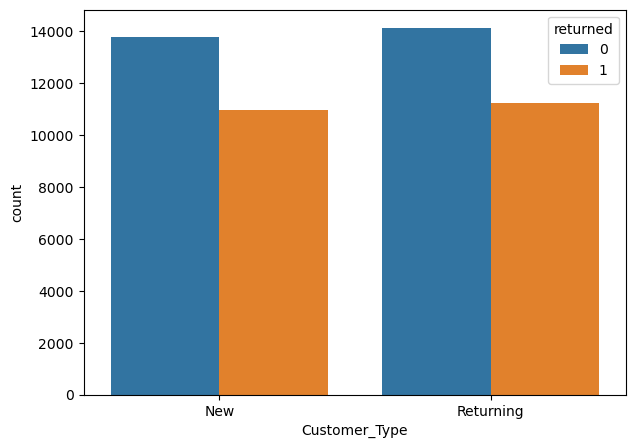

In [17]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Customer_Type",
    hue="returned"
)

plt.show()

## Returned vs Gender

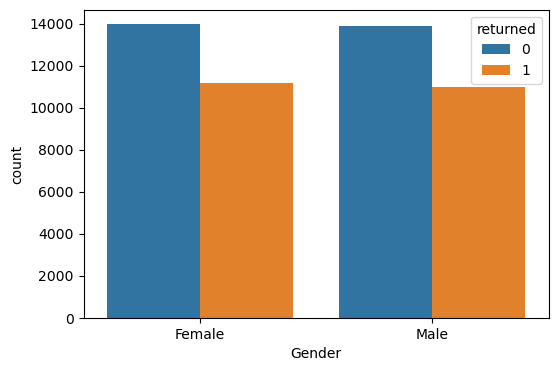

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="returned"
)

plt.show()

## Sales by Sales Channel

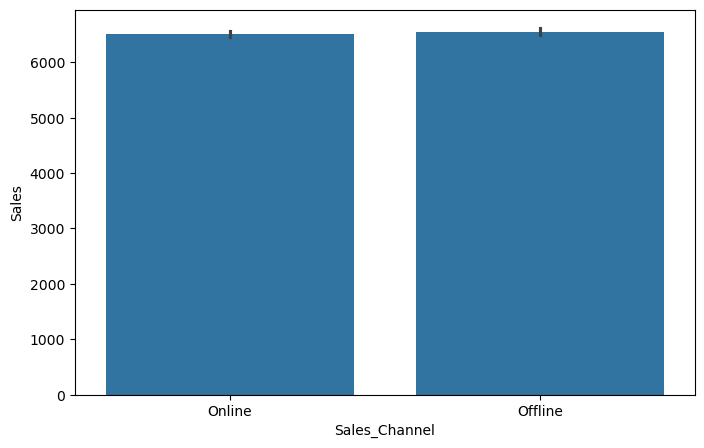

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Sales_Channel",
    y="Sales",
    estimator="mean"
)

plt.show()

## Profit by Sales Channel

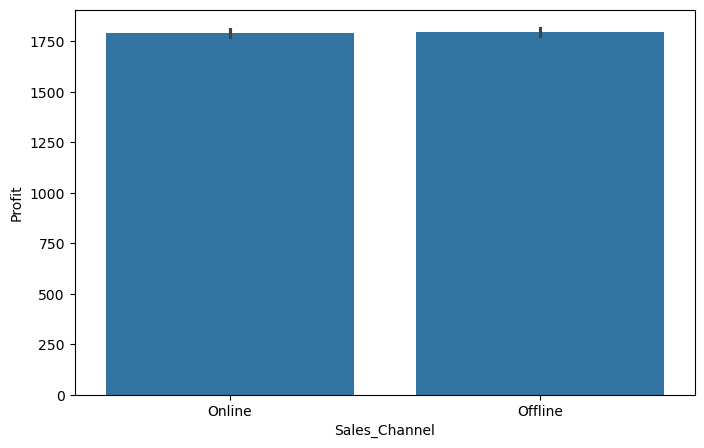

In [20]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Sales_Channel",
    y="Profit",
    estimator="mean"
)

plt.show()

## Correlation Heatmap

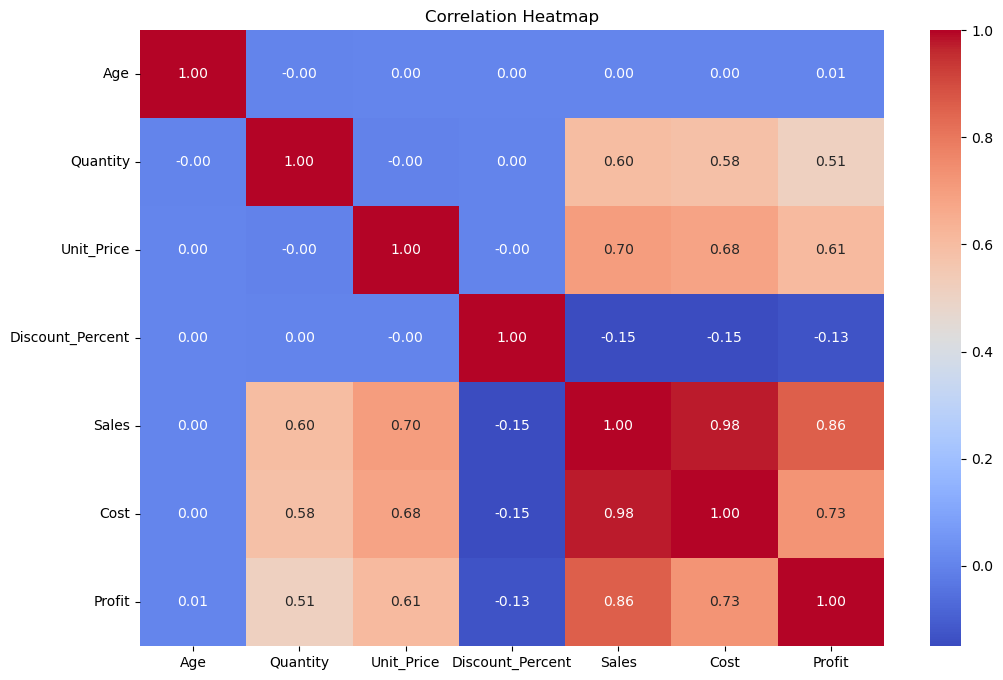

In [21]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Pairplot

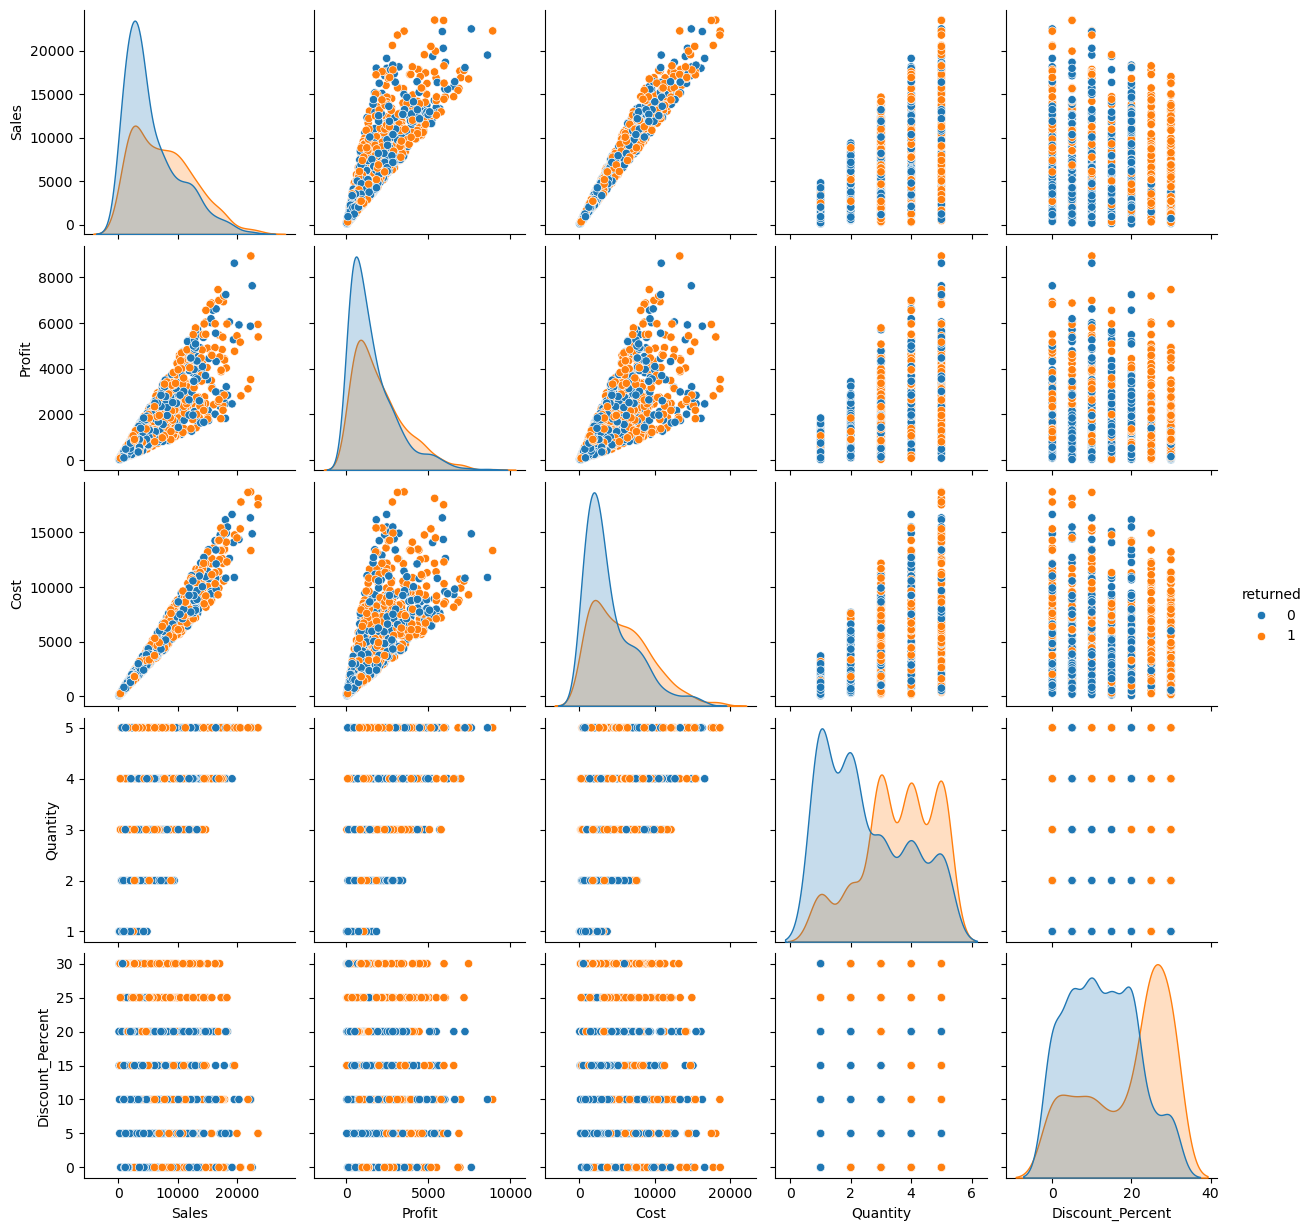

In [22]:
sample_df = df.sample(1000, random_state=42)

sns.pairplot(
    sample_df[
        [
            "Sales",
            "Profit",
            "Cost",
            "Quantity",
            "Discount_Percent",
            "returned"
        ]
    ],
    hue="returned"
)

plt.show()

## Sales vs Profit

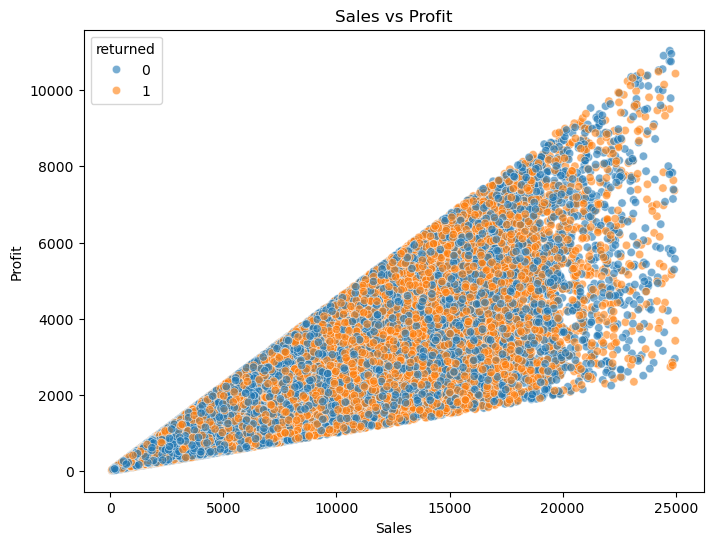

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="returned",
    alpha=0.6
)

plt.title("Sales vs Profit")

plt.show()

In [24]:
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Gender',
       'City', 'State', 'Region', 'Product_ID', 'Product_Name', 'Category',
       'Sub_Category', 'Brand', 'Payment_Method', 'Sales_Channel',
       'Sales_Person', 'Customer_Type'],
      dtype='object')

## Features aur Target Separate

In [26]:
X = df.drop(columns=[
    "returned",
    "Order_ID",
    "Customer_ID",
    "Customer_Name",
    "Product_ID",
    "Product_Name"
])

y = df["returned"]

## Feature Types Check

In [27]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical Columns:")
print(categorical_cols)

print("Numerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['Order_Date', 'Gender', 'City', 'State', 'Region', 'Category',
       'Sub_Category', 'Brand', 'Payment_Method', 'Sales_Channel',
       'Sales_Person', 'Customer_Type'],
      dtype='object')
Numerical Columns:
Index(['Age', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Sales', 'Cost',
       'Profit'],
      dtype='object')


## Stratified Train-Test Split

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [62]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (40000, 19)
X_test : (10000, 19)
y_train : (40000,)
y_test : (10000,)


## Numerical & Categorical Columns

In [63]:
categorical_cols = X_train.select_dtypes(include="object").columns

numerical_cols = X_train.select_dtypes(exclude="object").columns

print(categorical_cols)
print(numerical_cols)

Index(['Order_Date', 'Gender', 'City', 'State', 'Region', 'Category',
       'Sub_Category', 'Brand', 'Payment_Method', 'Sales_Channel',
       'Sales_Person', 'Customer_Type'],
      dtype='object')
Index(['Age', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Sales', 'Cost',
       'Profit'],
      dtype='object')


## Preprocessing

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

## Create Pipeline

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(random_state=42))
])

## Train Model

In [66]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'Quantity', 'Unit_Price', 'Discount_Percent', 'Sales', 'Cost',
       'Profit'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Order_Date', 'Gender', 'City', 'State', 'Region', 'Category',
       'Sub_Category', 'Brand', 'Payment_Method', 'Sales_Channel',
       'Sales_Person', 'Customer_Type'],
      dtype='object'))])),
                ('model', LogisticRegression(random_state=42))])

## Decision Tree Model

In [67]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ))
])

dt_pipeline.fit(X_train, y_train)

dt_pred = dt_pipeline.predict(X_test)
dt_prob = dt_pipeline.predict_proba(X_test)[:,1]

## Decision Tree Evaluation

In [68]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc = roc_auc_score(y_test, dt_prob)

print("Accuracy :", (dt_accuracy))
print("Precision :", (dt_precision))
print("Recall :", (dt_recall))
print("F1 Score :", (dt_f1))
print("ROC AUC :", (dt_roc))

Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0
ROC AUC : 1.0


## Prediction

In [36]:
y_pred = pipeline.predict(X_test)

In [37]:
y_pred

array([1, 0, 0, ..., 0, 1, 0])

## Classification Report

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.92      0.91      5570
           1       0.89      0.89      0.89      4430

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



## Confusion Matrix

In [46]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5107  463]
 [ 501 3929]]


## Confusion Matrix Visualization

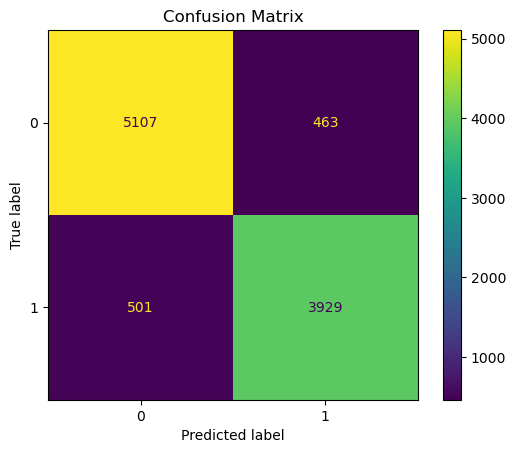

In [47]:
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

plt.title("Confusion Matrix")
plt.show()

## Feature Importance

## Feature Importance

In [69]:
dt_model = dt_pipeline.named_steps["model"]

feature_names = dt_pipeline.named_steps["preprocessor"].get_feature_names_out()

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,num__Quantity,0.329028
3,num__Discount_Percent,0.188092
785,cat__Category_Electronics,0.186485
820,cat__Payment_Method_Cash,0.166646
784,cat__Category_Clothing,0.129748
563,cat__Order_Date_2026-07-11,0.000000
564,cat__Order_Date_2026-07-12,0.000000
565,cat__Order_Date_2026-07-13,0.000000
566,cat__Order_Date_2026-07-14,0.000000
567,cat__Order_Date_2026-07-15,0.000000


## Graph

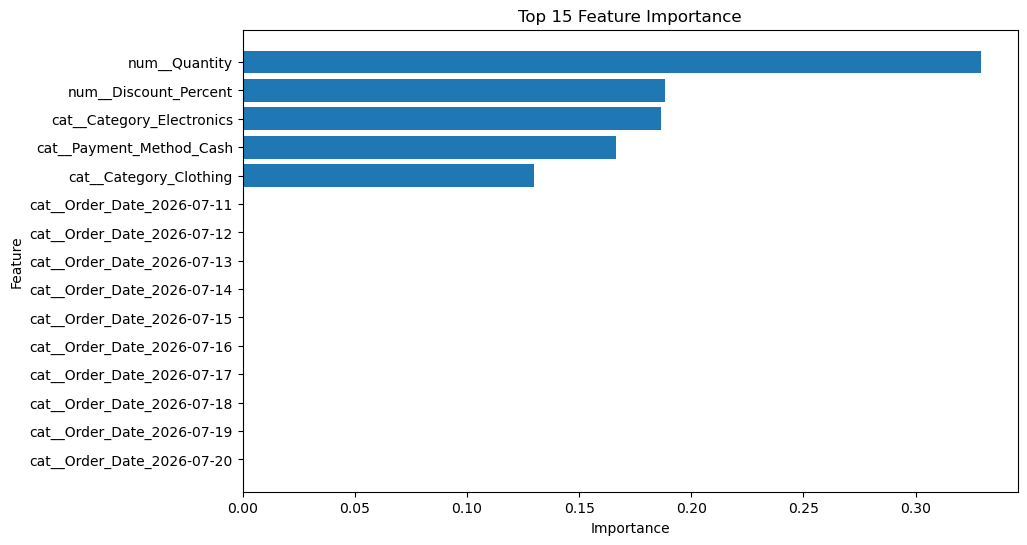

In [70]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(15)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Save Best Model

In [85]:
import joblib

joblib.dump(dt_pipeline, "return_prediction_model.pkl")

['return_prediction_model.pkl']

## Predict New Data

In [86]:
sample = X_test.iloc[[0]]

prediction = dt_pipeline.predict(sample)

print(prediction)

[1]


In [87]:
probability = model.predict_proba(X_test.iloc[[0]])[0][1]

print("Prediction: Returned")
print("Return Probability:", round(probability * 100, 2), "%")

Prediction: Returned
Return Probability: 100.0 %


In [88]:
def predict_return(data):
    prediction = model.predict(data)
    return prediction

In [89]:
import joblib

model = joblib.load("return_prediction_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [91]:
new_data = pd.DataFrame([{
    'Age': 30,
    'Quantity': 3,
    'Unit_Price': 500,
    'Discount_Percent': 10,
    'Sales': 1350,
    'Cost': 900,
    'Profit': 450,
    'Order_Date': '2026-08-10',
    'Gender': 'Male',
    'City': 'Jaipur',
    'State': 'Rajasthan',
    'Region': 'North',
    'Category': 'Electronics',
    'Sub_Category': 'Mobile',
    'Brand': 'Samsung',
    'Payment_Method': 'UPI',
    'Sales_Channel': 'Online',
    'Sales_Person': 'Rahul',
    'Customer_Type': 'Regular'
}])

prediction = model.predict(new_data)
print("Prediction:", prediction)

probability = model.predict_proba(new_data)
print("Probability:", probability)

Prediction: [1]
Probability: [[0. 1.]]
